# **Batches**
## Learning Objective
This notebook is to show you how to easily identify regions of data presence. 

## Prerequisites
You need albatros_analysis installed, and a basic understanding of how raw data is saved and organized. More information can be found on the [Data Structure Page](/pipeline/data_structure/).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from os import path
import sys
sys.path.insert(0, "/home/thomasb/")

# Baseband utils script
from albatros_analysis.src.utils import baseband_utils as butils

To check for data presence, you need to know where your data lives. Moreover, it's always useful to have a list of names that you can index through.

In [2]:
#data paths
ant_paths_all = np.array([
    '/project/rrg-sievers/albatros/mars/202507/mars1/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars2/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars3/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars4/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars5/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars6/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars7/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars8/baseband'
])

ant_names_all = np.array(["MARS1","MARS2","MARS3","MARS4","MARS5","MARS6","MARS7","MARS8"])

## 1. Choosing Where to Look
First we have to decide what antenna we want to look at, what time interval we care about, and what the time resolution is on our data search (a typical choice is 5 seconds)

In [3]:
interval_start, interval_end = 1761980000, 1762500000
T_SCAN = 5
desired_ant_idxs = [0, 1, 3, 4]

ant_paths = ant_paths_all[desired_ant_idxs]
ant_names = ant_names_all[desired_ant_idxs]

print(ant_names)
print(ant_paths)

['MARS1' 'MARS2' 'MARS4' 'MARS5']
['/project/rrg-sievers/albatros/mars/202507/mars1/baseband'
 '/project/rrg-sievers/albatros/mars/202507/mars2/baseband'
 '/project/rrg-sievers/albatros/mars/202507/mars4/baseband'
 '/project/rrg-sievers/albatros/mars/202507/mars5/baseband']


## 2. Binary File Presence
Next, we can determine an array of binary file presence or absence for all our desired antenna, for our entire interval.

1761979930 1762500000
1761979930 1762500000
1761979930 1762500000
1761979930 1762500000


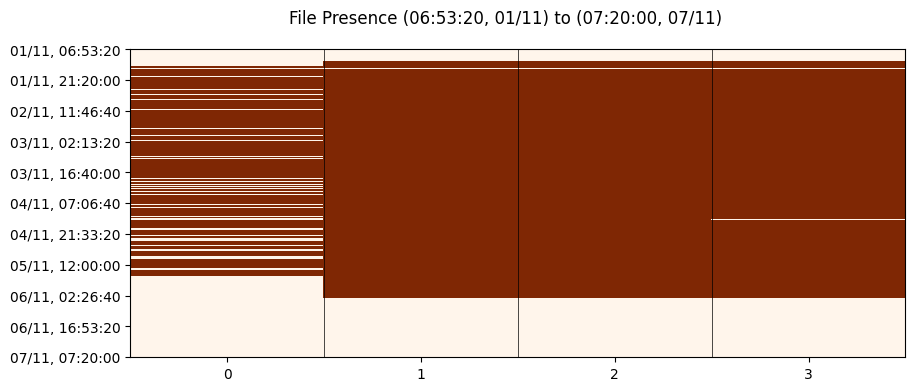

In [4]:
#determine file presence (get big array)
arr, fig = butils.get_present_files(interval_start, interval_end, ant_paths, T_SCAN = T_SCAN)

We can take a closer look at certain period of the time interval, and see that there are short reboot periods where all antenna are down. Continuous stretches of data (which we call batches) are therefore AT MOST one day long. They are, due to holes in the data, often shorter than this though.

1762184930 1762187000
1762184930 1762187000
1762184930 1762187000
1762184930 1762187000


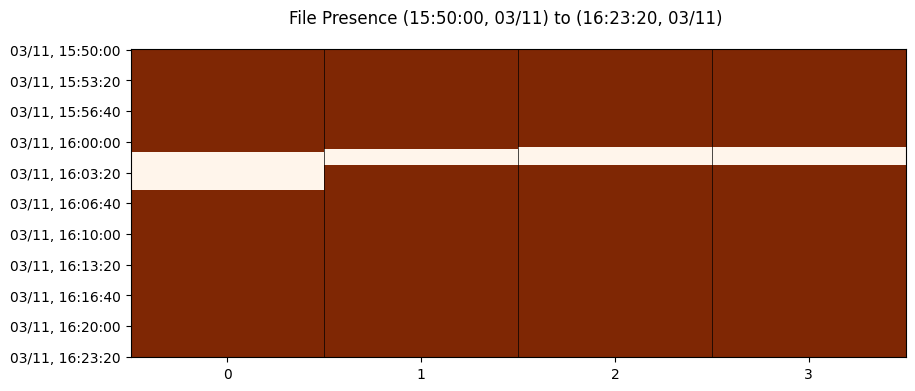

In [5]:
_ , _ = butils.get_present_files(1762185000, 1762187000, ant_paths, T_SCAN = T_SCAN)

## 3. Continuous Data Presence (A Batch)
Finally, we can determine all the contiguous stretches of data. We can select a different set of antenna indices (a subset of our first desired_ant_idxs selection) if we see that some antenna are particularly bad/patchy.

In [21]:
#if you want to include all antenna
#idxs2 = np.arange(len(desired_ant_idxs))

#if you want to exclude MARS 1 since it's ratty as hell
idxs2 = [1, 2, 3]

runs = butils.get_simul_files(arr, interval_start, T_SCAN, idxs2)
for i, r in enumerate(runs):
    print(f'batch {i}', r, 'dt:', r[1]-r[0])

batch 0 [1762000040, 1762012810] dt: 12770
batch 1 [1762012955, 1762035135] dt: 22180
batch 2 [1762035165, 1762035645] dt: 480
batch 3 [1762035675, 1762035725] dt: 50
batch 4 [1762035780, 1762036850] dt: 1070
batch 5 [1762036880, 1762036985] dt: 105
batch 6 [1762037020, 1762037285] dt: 265
batch 7 [1762037315, 1762037685] dt: 370
batch 8 [1762037710, 1762099215] dt: 61505
batch 9 [1762099355, 1762185620] dt: 86265
batch 10 [1762185755, 1762267835] dt: 82080
batch 11 [1762267860, 1762272035] dt: 4175
batch 12 [1762272160, 1762358430] dt: 86270
batch 13 [1762358570, 1762380595] dt: 22025
batch 14 [1762380625, 1762382610] dt: 1985
batch 15 [1762382640, 1762400025] dt: 17385


We see that (when exluding MARS1) there are some good, long batches of about 80k seconds. There are, however, some ratty shorter ones of duration order 100s that we cannot really use for analysis.

## Further Notes

We might also want to look at data presence only for certain frequencies.